# Decision Trees

## 🔗 Where we are in the story

So far, we have built two major paradigms of classification:

1. **K-Nearest Neighbors (KNN)** — an instance-based, non-parametric method that estimates the posterior $P(\text{class}\mid \mathbf{x})$ by looking at neighboring points.
2. **Logistic Regression** — a parametric, linear method that uses a hyperplane to divide classes, squashing outputs into $[0, 1]$ using the sigmoid.

While Logistic Regression is highly stable and elegant, it assumes classes can be separated by a **straight line** (or a hyperplane in higher dimensions). But what if the boundary is complex, non-linear, or resembles a flow-chart of logical rules? 

Enter **Decision Trees**: a non-parametric approach that breaks down the decision-making process into a series of simple, nested, axis-aligned questions.

---

# Part 1 — The Anatomy of a Decision Tree

## 💡 The model as a flowchart

A decision tree is a flowchart-like structure where:
- Each **internal node** represents a test on an attribute (e.g., "Is blood glucose > 125?").
- Each **branch** represents the outcome of the test (Yes / No).
- Each **leaf node** represents a class label or a continuous prediction.

Unlike logistic regression, which combines all features at once via $\mathbf{w}^\top \mathbf{x} + b$, decision trees inspect **one feature at a time**.

## 📐 2D example: non-linear classification boundary

Let's generate some synthetic data to see how a Decision Tree carves up a 2D space compared to a linear model.

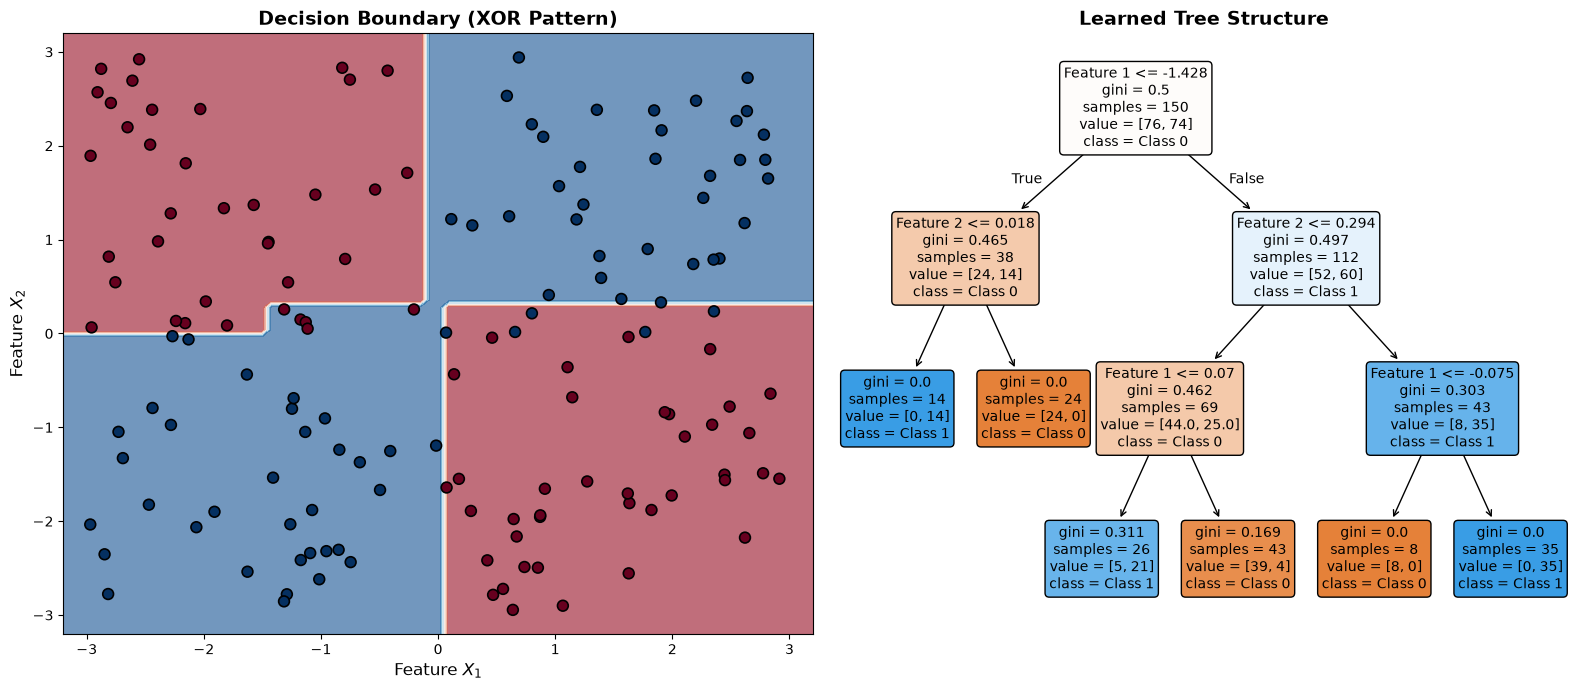

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay

# Set seed and figure aesthetics
np.random.seed(42)
plt.rcParams["figure.figsize"] = (16, 7) # Widened figure to fit two subplots
plt.rcParams['axes.facecolor'] = '#f8f9fa'

# --- Synthetic non-linear data (e.g., a cross pattern) ---
n = 150
X = np.random.uniform(-3, 3, (n, 2))
# Rule: positive if both are positive or both are negative (XOR gate)
y = (X[:, 0] * X[:, 1] > 0).astype(int)

# --- Train the Decision Tree ---
# We set max_depth=3. An unconstrained tree would overfit the noise, 
# creating an ugly, jagged boundary. Depth 3 captures the XOR cleanly.
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2)

# SUBPLOT 1: Decision Boundary
# Use a diverging colormap to clearly distinguish the two classes
DecisionBoundaryDisplay.from_estimator(
    clf, X, response_method="predict", 
    cmap='RdBu', alpha=0.6, ax=ax1
)

# Plot the actual data points on top
scatter = ax1.scatter(
    X[:, 0], X[:, 1], c=y, cmap='RdBu', 
    edgecolor='black', s=60, linewidth=1.2
)

ax1.set_title("Decision Boundary (XOR Pattern)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Feature $X_1$", fontsize=12)
ax1.set_ylabel("Feature $X_2$", fontsize=12)
ax1.set_xlim(-3.2, 3.2)
ax1.set_ylim(-3.2, 3.2)

# SUBPLOT 2: Tree Structure
plot_tree(
    clf, 
    feature_names=["Feature 1", "Feature 2"], 
    class_names=["Class 0", "Class 1"],
    filled=True,       # Colors the nodes based on majority class
    rounded=True,      # Rounds the corners of the nodes
    fontsize=10, 
    ax=ax2
)

ax2.set_title("Learned Tree Structure", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 🧠 Key takeaway

> While logistic regression creates a single straight diagonal boundary, a Decision Tree carves the space into **axis-aligned boxes**. This allows it to easily capture complex interactions like XOR without any feature engineering.

---

# Part 2 — How a Tree Splits (Gini vs. Entropy)

To build a tree from scratch, we must answer a fundamental question at each node: **Which feature and which threshold gives us the "best" split?**

To define "best", we need a mathematical measure of **impurity** (how mixed the classes are in a node). We want our splits to produce children nodes that are as **pure** (homogenous) as possible.

## ⚖️ Measure 1: Gini Impurity

Gini impurity measures the probability of a randomly chosen element being incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.

$$G = 1 - \sum_{i=1}^{C} p_i^2$$

- $p_i$ is the probability/fraction of items labeled with class $i$ in the node.
- If a node contains only one class (perfectly pure), $G = 1 - 1^2 = 0$.
- For binary classification, the maximum Gini impurity is $0.5$ (when classes are $50/50$).

## 🧪 Measure 2: Entropy (Information Theory)

Entropy measures the level of impurity, disorder, or surprise in a set of data.

$$H = -\sum_{i=1}^{C} p_i \log_2 p_i$$

- If a node is pure, $H = -(1 \log_2 1) = 0$.
- For binary classification, the maximum Entropy is $1.0$ (when classes are $50/50$).

Let's visualize Gini vs. Entropy as the proportion of positive samples $p$ varies from $0$ to $1$:

Both metrics behave almost identically in terms of where their minimums (0 and 1) and maximums (0.5) lie. Gini impurity is often preferred in practice because it doesn't require computing computationally expensive logarithms.

## 🎯 Information Gain: Choosing the Best Split

The utility of a split is quantified by **Information Gain** — the reduction in impurity after partitioning the data:

$$IG(T, a) = I(T) - \left( \frac{|T_{\text{left}}|}{|T|} I(T_{\text{left}}) + \frac{|T_{\text{right}}|}{|T|} I(T_{\text{right}}) \right)$$

Where:
- $T$ is the parent node, $T_{\text{left}}$ and $T_{\text{right}}$ are the child nodes.
- $I(\cdot)$ is our chosen impurity metric (Gini or Entropy).
- we select the feature and split value $a$ that **maximizes** $IG$.

---

# Part 3 — Overfitting & Regularization

Because decision trees can keep splitting until every single leaf is pure, they are highly prone to **overfitting** — memorizing training noise instead of learning general rules.

Let's compare an unconstrained tree with a regularized one:

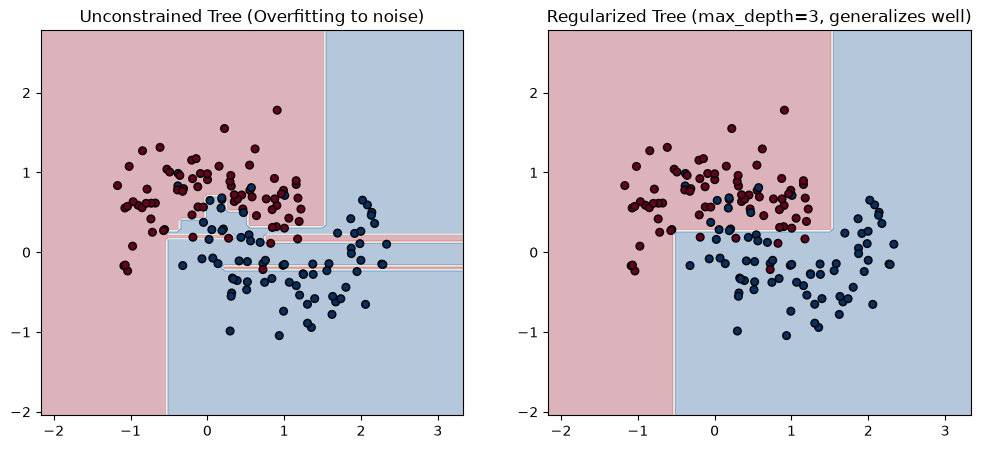

In [21]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay

X, y = make_moons(n_samples=150, noise=0.3, random_state=432)

# --- Fit two trees: one shallow, one completely unconstrained ---
clf_overfit = DecisionTreeClassifier(random_state=42)  # no constraints
clf_regularized = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)

clf_overfit.fit(X, y)
clf_regularized.fit(X, y)

# --- Plot the results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Overfitted
DecisionBoundaryDisplay.from_estimator(clf_overfit, X, cmap="RdBu", alpha=0.3, ax=ax1, response_method="predict")
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k", s=30)
ax1.set_title("Unconstrained Tree (Overfitting to noise)")

# Regularized
DecisionBoundaryDisplay.from_estimator(clf_regularized, X, cmap="RdBu", alpha=0.3, ax=ax2, response_method="predict")
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k", s=30)
ax2.set_title("Regularized Tree (max_depth=3, generalizes well)")

plt.show()

### 🛠️ Common Regularization Hyperparameters

- **`max_depth`**: Limits how deep the tree can grow.
- **`min_samples_split`**: The minimum number of samples a node must have to be allowed to split.
- **`min_samples_leaf`**: The minimum number of samples a leaf node must contain.
- **`max_leaf_nodes`**: Limits the total number of leaves in the tree.

---

# Part 4 — Inspecting and Interpreting a Tree

One of the greatest features of decision trees is **interpretability**. Unlike deep neural networks, we can print out the exact rules a tree learned.

Let's fit a simple tree and draw it:

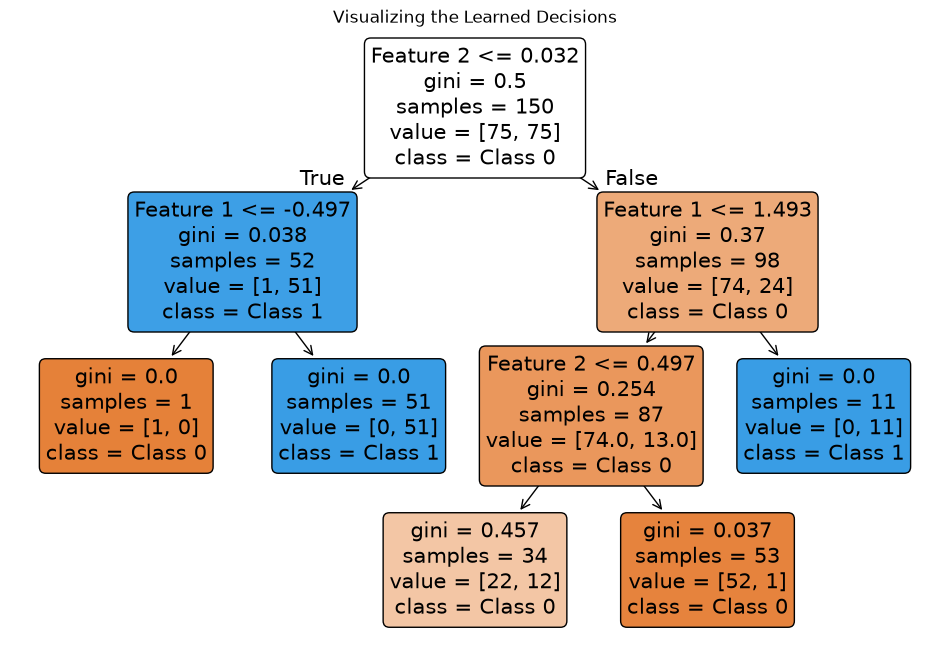

In [12]:
from sklearn.tree import plot_tree

# Fit a small tree on synthetic 2D data
clf_small = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_small.fit(X, y)

# Render the tree structure
plt.figure(figsize=(12, 8))
plot_tree(
    clf_small,
    filled=True,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    rounded=True
)
plt.title("Visualizing the Learned Decisions")
plt.show()

### 📊 Feature Importances

Decision trees automatically compute which features are most useful for predicting the target. A feature's importance is calculated as the sum of Gini/Entropy reductions it achieves across all nodes it splits:

In [13]:
importances = clf_regularized.feature_importances_
print("Feature Importances:")
for i, imp in enumerate(importances):
    print(f"Feature {i+1}: {imp:.3f}")

Feature Importances:
Feature 1: 0.259
Feature 2: 0.741


---

# Part 5 — Summary & Comparison

Let's place Decision Trees into context alongside our other algorithms:

| Concept | KNN | Logistic Regression | Decision Trees |
|---|---|---|---|
| **Type** | Non-parametric, Instance-based | Parametric, Linear | Non-parametric, Tree-based |
| **Decision Boundary** | Wiggly, complex, local | Straight line / Hyperplane | Axis-aligned splits (nested rectangles) |
| **Feature Scaling?** | ⚠️ **Required** (highly sensitive to distance) | ⚠️ **Recommended** (helps gradient descent) | ✅ **Not Required** (invariant to monotonic scaling) |
| **Interpretability** | Moderate (just points) | High (coefficients/weights $\mathbf{w}$) | 🏆 **Excellent** (flowchart rules) |
| **Overfitting Risk** | High if $K$ is too small | Low (highly constrained) | High (needs depth limits) |
| **Handling of Outliers** | Sensitive | Moderate | Highly robust (splits don't care about extreme values) |

Decision trees are powerful and intuitive, but single trees suffer from high variance (they change drastically with slight changes in training data). To fix this, we combine multiple trees into **ensembles** (such as Random Forests and Gradient Boosted Trees), which represent the state-of-the-art for tabular data today!